# MaldiAMRKit - Drift Monitoring

This notebook demonstrates `maldiamrkit.drift.DriftMonitor`, which anchors
a baseline on the earliest timestamps and tracks temporal drift through
three complementary views:

- **Reference similarity** - distance of per-window median spectrum to
  the baseline reference (no labels needed)
- **PCA centroid trajectory** - how windows move in a baseline-fitted
  PCA space
- **Peak-selection stability + effect-size drift** - Jaccard overlap of
  top-k discriminative peaks per window vs. baseline, and Cohen's d of
  specific peaks over time

## Load the Dataset

We load the bundled 29-spectrum dataset and augment it with synthetic
dated samples to produce a time series long enough for meaningful
monitoring. This is a notebook-only trick - never augment this way in real
analyses.

In [1]:
import numpy as np
import pandas as pd

from maldiamrkit import MaldiSet
from maldiamrkit.evaluation import LabelEncoder

data = MaldiSet.from_directory(
    "../data/",
    "../data/metadata/metadata.csv",
    aggregate_by=dict(antibiotics="Drug"),
    bin_width=3,
)
encoder = LabelEncoder(intermediate="drop")
labels_raw = data.get_y_single("Drug")
y_arr = encoder.fit_transform(labels_raw)
y = pd.Series(y_arr, index=labels_raw.index, name="y").dropna().astype(int)
X = data.X.loc[y.index]
print(f"Real rows: {X.shape}, class counts: {y.value_counts().to_dict()}")

/home/ettore/.venvs/maldiamrkit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Real rows: (29, 6000), class counts: {0: 19, 1: 10}


### Augment with Dated Synthetic Samples

We generate 150 synthetic spectra spaced evenly across 180 days:

- Gaussian noise on top of the mean real spectrum (realistic baseline
  shape)
- 6 R-specific and 6 S-specific injected peaks (stable discriminative
  signal)
- **Drift injected** in the final third of the timeline: intensity at
  the first 5 m/z bins is scaled up, simulating an instrument shift
- TIC normalization per row

We then build an augmented `MaldiSet`-like shim that exposes `.X`,
`.meta`, and `.get_y_single()` - everything `DriftMonitor` needs.

In [2]:
from dataclasses import dataclass


@dataclass
class TimestampedSet:
    """Helper class to hold spectra and metadata together for drift monitoring."""

    X: pd.DataFrame
    meta: pd.DataFrame

    def get_y_single(self, antibiotic: str | None = None) -> pd.Series:
        """Get the class labels for the given antibiotic (or "Drug" if None)."""
        col = antibiotic or "Drug"
        return self.meta.loc[self.X.index, col]


rng = np.random.default_rng(42)
n_synth = 150
n_features = X.shape[1]

template = X.mean()
r_bins = list(rng.choice(X.columns, size=6, replace=False))
s_bins = list(
    rng.choice([c for c in X.columns if c not in r_bins], size=6, replace=False)
)

noise = rng.normal(0.0, 0.25 * template.mean(), size=(n_synth, n_features))
synth = np.clip(template.to_numpy() + noise, 0.0, None)
synth_labels = rng.integers(0, 2, size=n_synth)

for b in r_bins:
    j = X.columns.get_loc(b)
    synth[synth_labels == 1, j] += 80.0 * template.mean()
for b in s_bins:
    j = X.columns.get_loc(b)
    synth[synth_labels == 0, j] += 80.0 * template.mean()

# Dates: 150 rows spread across 180 days
start = pd.Timestamp("2025-01-01")
days = np.sort(rng.integers(0, 180, size=n_synth))
dates_synth = [start + pd.Timedelta(days=int(d)) for d in days]

# Inject drift: intensity on the first 5 columns scales up in the
# final 60 days ("post-baseline" shift mimicking an instrument issue)
shift_mask = np.array(days) >= 120
drift_cols_idx = np.arange(5)
col_baseline_std = synth[:, drift_cols_idx].std(axis=0) + 1e-12
synth[np.ix_(shift_mask, drift_cols_idx)] += 4.0 * col_baseline_std

# TIC normalize
synth = synth / synth.sum(axis=1, keepdims=True)

X_synth = pd.DataFrame(
    synth,
    columns=X.columns,
    index=[f"synth_{i:03d}" for i in range(n_synth)],
)
y_synth = pd.Series(
    synth_labels,
    index=X_synth.index,
    name="Drug",
).astype(int)

# Real rows get dates uniformly across the first 60 days (baseline era)
real_dates = [
    start + pd.Timedelta(days=int(d)) for d in np.linspace(0, 60, len(X), dtype=int)
]

X_full = pd.concat([X, X_synth])
meta_full = pd.DataFrame(
    {
        "Drug": pd.concat([y, y_synth]).astype(int),
        "acquisition_date": real_dates + dates_synth,
    },
    index=X_full.index,
)

dataset = TimestampedSet(X=X_full, meta=meta_full)
print(
    f"Augmented: {X_full.shape}, "
    f"class counts: {meta_full['Drug'].value_counts().to_dict()}"
)
print(
    f"Date range: {meta_full['acquisition_date'].min().date()} "
    f"→ {meta_full['acquisition_date'].max().date()}"
)

Augmented: (179, 6000), class counts: {0: 104, 1: 75}
Date range: 2025-01-01 → 2025-06-29


## Fit the DriftMonitor

By default, the baseline is the earliest 20% of sorted timestamps. Below
we use a 30-day sliding window.

In [3]:
from maldiamrkit.drift import DriftMonitor

monitor = DriftMonitor(
    time_column="acquisition_date",
    window="30D",
    metric="cosine",
    min_samples=5,
).fit(dataset)
print(f"Baseline cutoff: {monitor.baseline_end_.date()}")

Baseline cutoff: 2025-01-27


## 1. Reference Similarity

For each 30-day window we compute the median spectrum and measure its
cosine distance to the baseline reference (element-wise median of
baseline rows). A rising line signals that the population is drifting
away from the baseline fingerprint.

In [4]:
from maldiamrkit.drift import plot_reference_drift

ref_df = monitor.monitor(dataset)
ref_df

,window_start,window_end,n_spectra,distance_to_reference
0,2025-01-01,2025-01-31,37,0.000071
1,2025-01-31,2025-03-02,37,0.001451
2,2025-03-02,2025-04-01,27,0.423041
3,2025-04-01,2025-05-01,27,0.422501
4,2025-05-01,2025-05-31,28,0.424281
5,2025-05-31,2025-06-30,23,0.424229


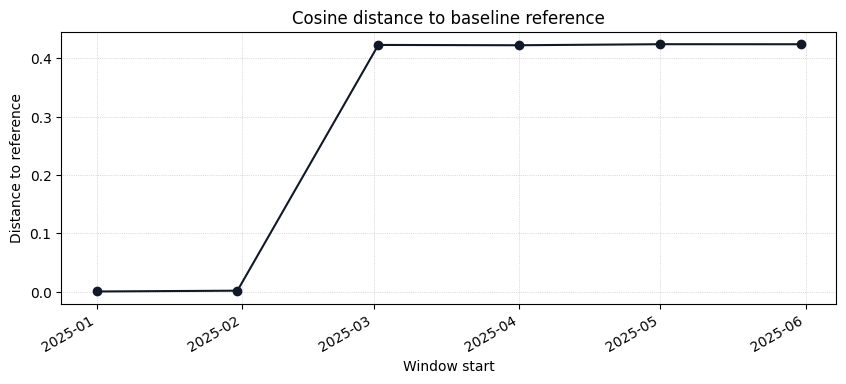

In [5]:
_ = plot_reference_drift(
    ref_df,
    title="Cosine distance to baseline reference",
)

## 2. PCA Centroid Trajectory

`monitor_pca` projects each window's rows onto a PCA space fitted on
the baseline, then reports the per-window centroid (PC1, PC2) and
dispersion (mean distance from centroid).

`plot_pca_drift` draws arrows between consecutive centroids and colors
each point by time (early → late).

In [6]:
from maldiamrkit.drift import plot_pca_drift

pca_df = monitor.monitor_pca(dataset)
pca_df

,window_start,window_end,centroid_pc1,centroid_pc2,dispersion,n_spectra
0,2025-01-01,2025-01-31,-0.000707,0.000034,0.019268,37
1,2025-01-31,2025-03-02,-0.002865,0.001249,0.018485,37
2,2025-03-02,2025-04-01,0.001568,0.007196,0.020925,27
3,2025-04-01,2025-05-01,-0.000678,0.008308,0.021292,27
4,2025-05-01,2025-05-31,0.003054,0.007845,0.020327,28
5,2025-05-31,2025-06-30,0.004945,0.007632,0.019346,23


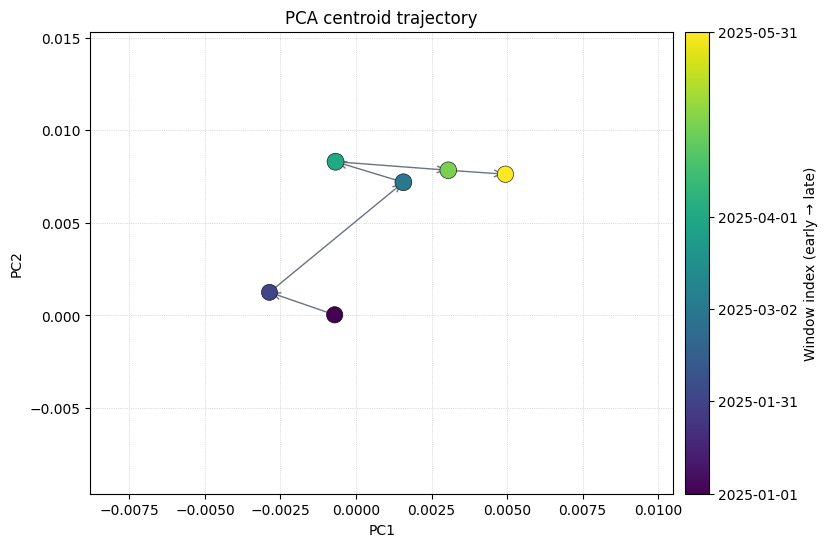

In [7]:
_ = plot_pca_drift(pca_df, title="PCA centroid trajectory")

## 3. Peak-Selection Stability

For each window, `monitor_peak_stability` fits a fresh
`DifferentialAnalysis` and computes the Jaccard overlap of its top-k
peaks with the baseline top-k. A falling curve means discriminative
peaks are shifting over time - a red flag for biomarker studies.

We first build the baseline analysis on the full augmented dataset.

In [8]:
from maldiamrkit.differential import DifferentialAnalysis
from maldiamrkit.drift import plot_peak_stability

baseline_analysis = DifferentialAnalysis(X_full, meta_full["Drug"]).run()
stability_df = monitor.monitor_peak_stability(
    dataset,
    baseline_analysis,
    antibiotic="Drug",
    n_top=15,
)
stability_df

,window_start,stability_score,n_spectra
0,2025-01-01,0.250000,37
1,2025-01-31,0.363636,37
2,2025-03-02,0.666667,27
3,2025-04-01,0.666667,27
4,2025-05-01,0.666667,28
5,2025-05-31,0.666667,23


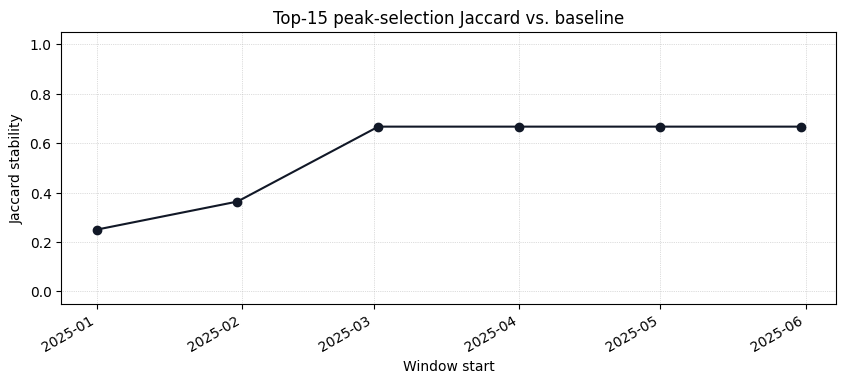

In [9]:
_ = plot_peak_stability(
    stability_df,
    title="Top-15 peak-selection Jaccard vs. baseline",
)

## 4. Per-Peak Effect-Size Drift

If you already have a short list of peaks of interest (e.g., from the
baseline analysis), `monitor_effect_sizes` tracks their Cohen's d
between R and S in each window. A peak whose d drops toward zero (or
flips sign) is losing discriminative power.

In [10]:
from maldiamrkit.drift import plot_effect_size_drift

top5 = baseline_analysis.top_peaks(n=5)["mz_bin"].astype(str).tolist()
effect_df = monitor.monitor_effect_sizes(
    dataset,
    peaks=top5,
    antibiotic="Drug",
)
effect_df

,window_start,3605.0,15920.0,9896.0,17453.0,13775.0
0,2025-01-01,2.509169,2.500138,2.520235,2.498795,2.498062
1,2025-01-31,1.982486,1.973540,1.970140,1.968716,1.979022
2,2025-03-02,273.619775,326.514439,273.143586,345.669281,281.463979
3,2025-04-01,254.583487,254.929692,223.654342,266.823324,324.501854
4,2025-05-01,300.490437,298.725645,321.078889,261.851933,244.218927
5,2025-05-31,275.393492,412.381008,234.969908,373.207572,337.224501


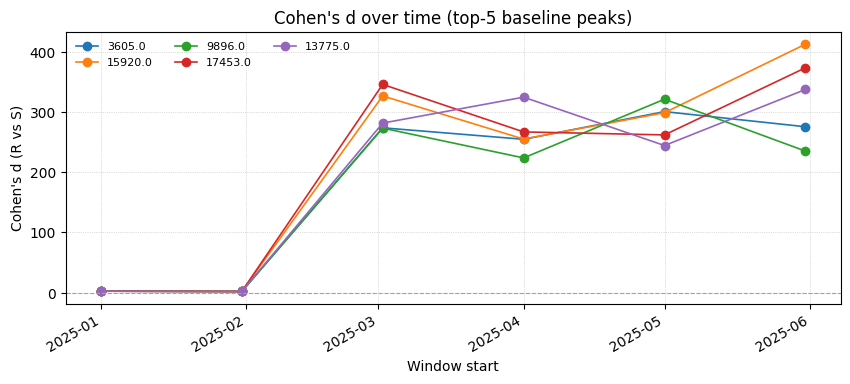

In [11]:
_ = plot_effect_size_drift(
    effect_df,
    title="Cohen's d over time (top-5 baseline peaks)",
)

## See Also

- [API Reference - Drift](https://maldiamrkit.readthedocs.io/api/drift.html)
- [Differential Analysis notebook](06_differential_analysis.ipynb)
  for the `DifferentialAnalysis` class that `monitor_peak_stability`
  reuses internally.